##Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Load datasets

In [3]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


##Check Dataset Information

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


##Data Cleaning
**Check missing values**

In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


##Check Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

##EDA
**Age Distribution**

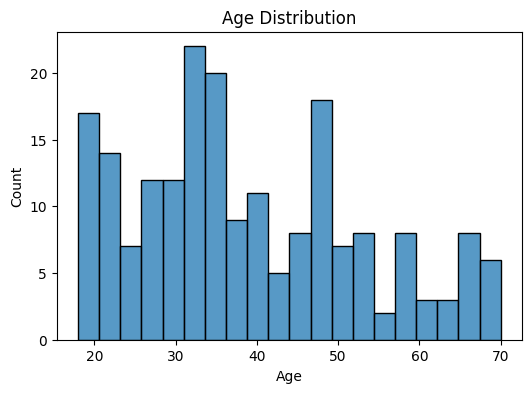

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"],bins=20)
plt.title("Age Distribution")
plt.show()

##Gender Distribution

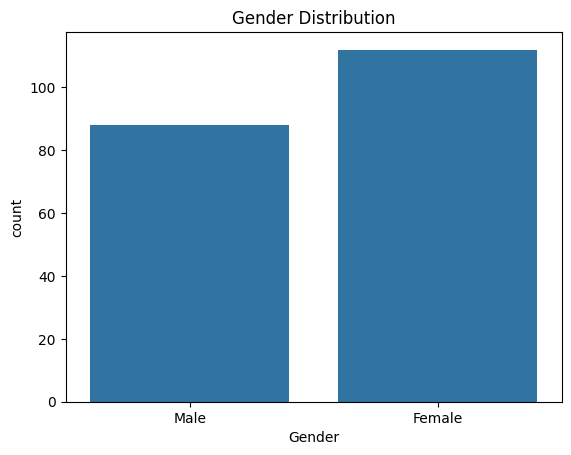

In [8]:
sns.countplot(x="Gender",data=df)
plt.title("Gender Distribution")
plt.show()

##Income Distribution

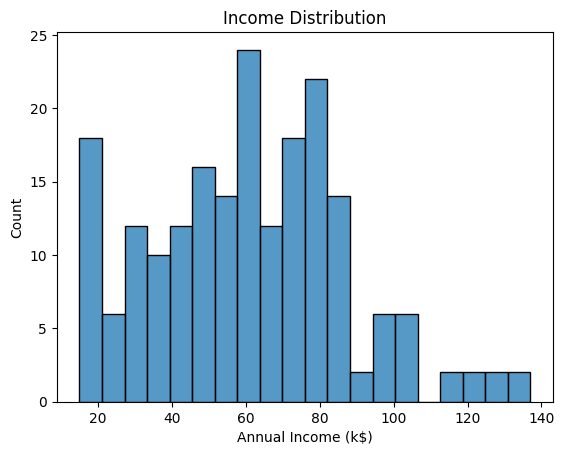

In [9]:
sns.histplot(df['Annual Income (k$)'],bins=20)
plt.title("Income Distribution")
plt.show()

##Spending Score Distribution

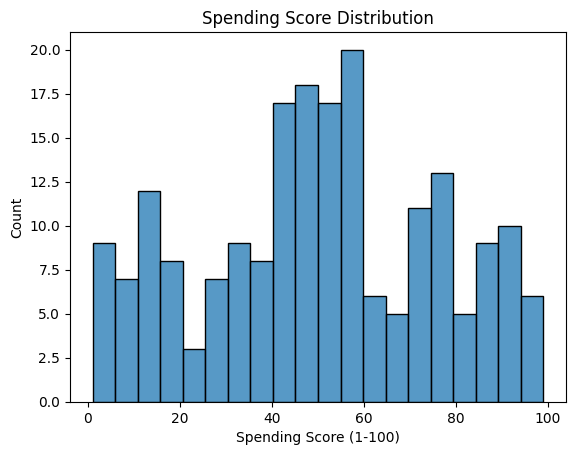

In [10]:
sns.histplot(df['Spending Score (1-100)'],bins=20)
plt.title("Spending Score Distribution")
plt.show()

##Income VS Spending

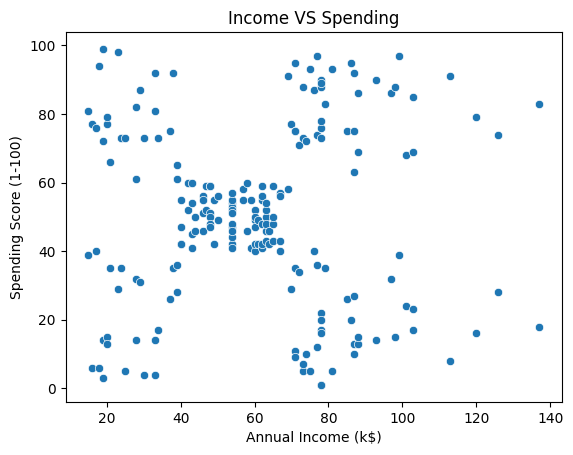

In [11]:
sns.scatterplot(x="Annual Income (k$)",
                y="Spending Score (1-100)",
                data=df
                )
plt.title("Income VS Spending")
plt.show()

##Select Features

In [12]:
X=df[['Annual Income (k$)',
      'Spending Score (1-100)']]

##Find Best Number of Clusters

In [13]:
from sklearn.cluster import KMeans
wcss= []
for i in range(1,11):
  Kmeans = KMeans(n_clusters=i,
                  random_state=42
                  )
  Kmeans.fit(X)
  wcss.append(Kmeans.inertia_)

##Plot Elbow Curve

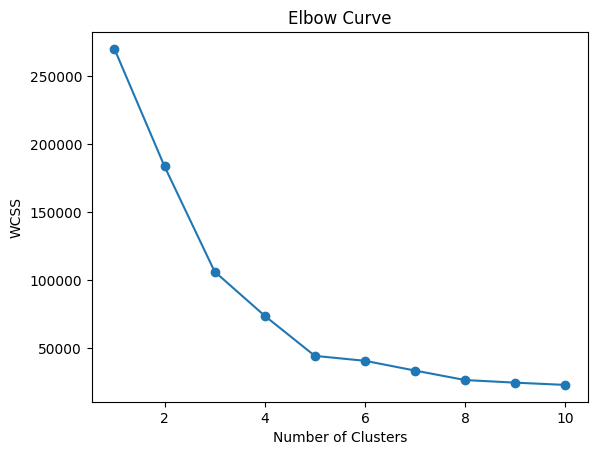

In [14]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Curve")
plt.show()

##Apply K-means

In [15]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)
df['Cluster'] = kmeans.fit_predict(X)

##Check Result

In [16]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


##Visualize Customer Segments

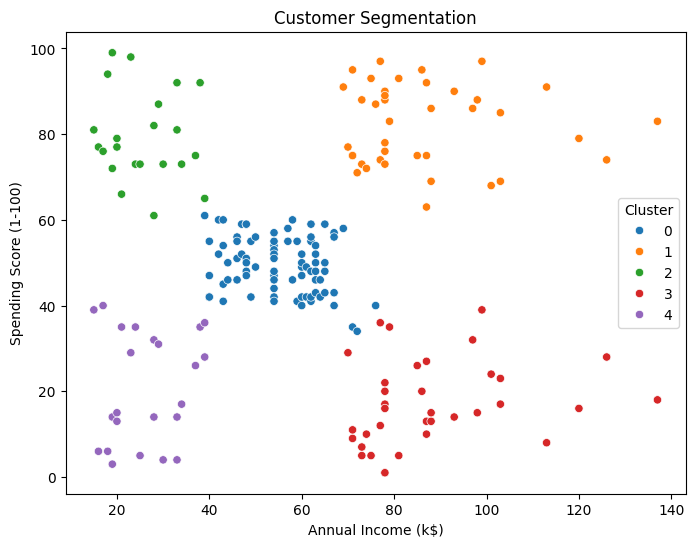

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='tab10',
    data=df
)
plt.title("Customer Segmentation")
plt.show()

##Analyse Clusters

In [22]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043
